In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

In [14]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

📤 Upload CONTENT image (jpg/jpeg/png)


Saving dog.jpg to dog (1).jpg
📤 Upload STYLE image (jpg/jpeg/png)


Saving wikiart.jpg to wikiart (1).jpg
✅ Images uploaded and loaded successfully!
Content image shape: torch.Size([1, 3, 512, 512])
Style image shape: torch.Size([1, 3, 512, 512])


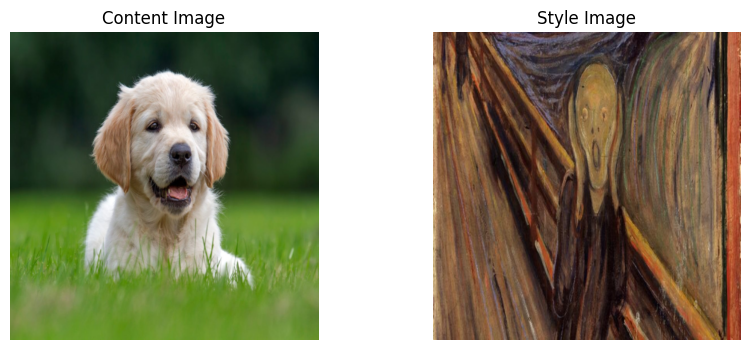

In [15]:
from google.colab import files

# Image size
imsize = 512 if torch.cuda.is_available() else 256

# Transform
loader = transforms.Compose([
    transforms.Resize((imsize, imsize)),
    transforms.ToTensor()
])

# Load image function
def load_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image = loader(image).unsqueeze(0)  # Add batch dimension
    return image.to(device, torch.float)

# Upload CONTENT image
print("📤 Upload CONTENT image (jpg/jpeg/png)")
content_upload = files.upload()
content_path = list(content_upload.keys())[0]

# Upload STYLE image
print("📤 Upload STYLE image (jpg/jpeg/png)")
style_upload = files.upload()
style_path = list(style_upload.keys())[0]

# Load images
content_img = load_image(content_path)
style_img = load_image(style_path)

# Check size
assert content_img.size() == style_img.size(), "❌ Content and Style images must be the same size!"

print("✅ Images uploaded and loaded successfully!")
print("Content image shape:", content_img.shape)
print("Style image shape:", style_img.shape)

# Show images
def imshow(tensor, title=None):
    image = tensor.cpu().clone()
    image = image.squeeze(0)
    image = transforms.ToPILImage()(image)
    plt.imshow(image)
    if title:
        plt.title(title)
    plt.axis("off")

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
imshow(content_img, "Content Image")

plt.subplot(1,2,2)
imshow(style_img, "Style Image")
plt.show()

In [16]:
# Load Pretrained VGG19
vgg = models.vgg19(pretrained=True).features.to(device).eval()

# Freeze VGG weights
for param in vgg.parameters():
    param.requires_grad = False


In [17]:
# Layers for content and style
content_layers = ['conv_4']
style_layers = ['conv_1', 'conv_2', 'conv_3', 'conv_4', 'conv_5']

# Map layer names to VGG indices
vgg_layers = {
    '0': 'conv_1',
    '5': 'conv_2',
    '10': 'conv_3',
    '19': 'conv_4',
    '28': 'conv_5'
}

In [18]:
# Feature Extraction
def get_features(image, model):
    features = {}
    x = image
    for name, layer in model._modules.items():
        x = layer(x)
        if name in vgg_layers:
            layer_name = vgg_layers[name]
            features[layer_name] = x
    return features

In [19]:
# Gram Matrix for Style Loss
def gram_matrix(tensor):
    b, c, h, w = tensor.size()
    features = tensor.view(c, h * w)
    G = torch.mm(features, features.t())
    return G / (c * h * w)


In [20]:
# Extract features
content_features = get_features(content_img, vgg)
style_features   = get_features(style_img, vgg)

# Compute Gram matrices for style
style_grams = {layer: gram_matrix(style_features[layer]) for layer in style_features}

In [21]:
# Initialize target image
target = content_img.clone().requires_grad_(True).to(device)

In [22]:
# Weights
style_weight = 1e6
content_weight = 1

# Optimizer
optimizer = optim.Adam([target], lr=0.01)

In [23]:
# Training Loop
num_steps = 1000

for step in range(1, num_steps+1):
    target_features = get_features(target, vgg)

    # Content Loss
    content_loss = torch.mean((target_features['conv_4'] - content_features['conv_4'])**2)

    # Style Loss
    style_loss = 0
    for layer in style_layers:
        target_feature = target_features[layer]
        target_gram = gram_matrix(target_feature)
        style_gram = style_grams[layer]
        layer_style_loss = torch.mean((target_gram - style_gram)**2)
        style_loss += layer_style_loss

    # Total Loss
    total_loss = content_weight * content_loss + style_weight * style_loss

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    if step % 50 == 0:
        print(f"Step {step}/{num_steps} | "
              f"Content Loss: {content_loss.item():.4f} | "
              f"Style Loss: {style_loss.item():.4f}")

Step 50/1000 | Content Loss: 0.4994 | Style Loss: 0.0000
Step 100/1000 | Content Loss: 0.4510 | Style Loss: 0.0000
Step 150/1000 | Content Loss: 0.4317 | Style Loss: 0.0000
Step 200/1000 | Content Loss: 0.4299 | Style Loss: 0.0000
Step 250/1000 | Content Loss: 0.4192 | Style Loss: 0.0000
Step 300/1000 | Content Loss: 0.4232 | Style Loss: 0.0000
Step 350/1000 | Content Loss: 0.4157 | Style Loss: 0.0000
Step 400/1000 | Content Loss: 0.4128 | Style Loss: 0.0000
Step 450/1000 | Content Loss: 0.4075 | Style Loss: 0.0000
Step 500/1000 | Content Loss: 0.4056 | Style Loss: 0.0000
Step 550/1000 | Content Loss: 0.4105 | Style Loss: 0.0000
Step 600/1000 | Content Loss: 0.4108 | Style Loss: 0.0000
Step 650/1000 | Content Loss: 0.4126 | Style Loss: 0.0000
Step 700/1000 | Content Loss: 0.4100 | Style Loss: 0.0000
Step 750/1000 | Content Loss: 0.4089 | Style Loss: 0.0000
Step 800/1000 | Content Loss: 0.4022 | Style Loss: 0.0000
Step 850/1000 | Content Loss: 0.4069 | Style Loss: 0.0000
Step 900/1000 |

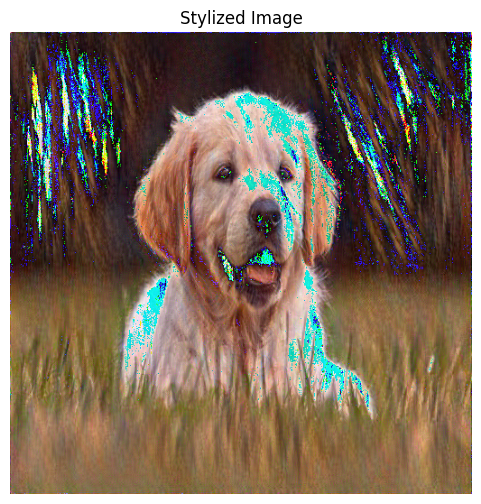

In [24]:
# Show Result
plt.figure(figsize=(6,6))
imshow(target, "Stylized Image")
plt.show()